In [14]:
# we need to run on a py file instead of a jupyter notebook otherwise multiprocessing will not work properly
import os
import sys

# agent.py / monte_carlo_tree_search.py / minimax.py import `Team2.data_processing`,
# so the repo root (the parent of Team2/) has to be on sys.path. This notebook lives in
# Team2/, so sys.path already covers `agent` and `model_files` themselves.
TEAM2_DIR = os.path.abspath("")
REPO_ROOT = os.path.dirname(TEAM2_DIR)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from agent import Agent, pit
from model_files.SLPolicyValueGPU import SLPolicyValueNetwork
import torch
import chess


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)

WEIGHTS_PATH = os.path.join(TEAM2_DIR, "model_weights", "lab_trained_epoch_1.pth")

model1 = SLPolicyValueNetwork().to(device)
checkpoint = torch.load(WEIGHTS_PATH, map_location=device)
model1.load_state_dict(checkpoint["model"])
model1.eval()

agent = Agent(policy_value_network=model1, c_puct=0.5, dirichlet_alpha=0.3, dirichlet_epsilon=0.3)
# epsilon is set to 0 for no noise

mcts_policy_temp = 1.0 #setting temp to 1 means no temperature (temperature for policy)
mcts_temp = 0.1 # <1 means we boost the uct scores of top moves
sims = 500

using device: cpu


('g1f3', [('g1f3', np.float64(50.0), np.float32(0.08698665), np.float32(24.478695)), ('e2e4', np.float64(47.0), np.float32(0.10657084), np.float32(23.463898)), ('f2f4', np.float64(43.0), np.float32(0.08910488), np.float32(20.52819)), ('g2g3', np.float64(34.0), np.float32(0.079650134), np.float32(16.511356)), ('b1c3', np.float64(33.0), np.float32(0.092426404), np.float32(16.393478)), ('h2h3', np.float64(32.0), np.float32(0.106894016), np.float32(16.002045)), ('d2d4', np.float64(32.0), np.float32(0.103637666), np.float32(16.103947)), ('h2h4', np.float64(31.0), np.float32(0.10496539), np.float32(15.829836)), ('c2c4', np.float64(31.0), np.float32(0.113336734), np.float32(14.713605)), ('g2g4', np.float64(26.0), np.float32(0.10327167), np.float32(13.169294)), ('g1h3', np.float64(21.0), np.float32(0.12070511), np.float32(10.625749)), ('d2d3', np.float64(21.0), np.float32(0.08493825), np.float32(10.098886)), ('b2b3', np.float64(20.0), np.float32(0.088110715), np.float32(9.794145)), ('a2a3', np

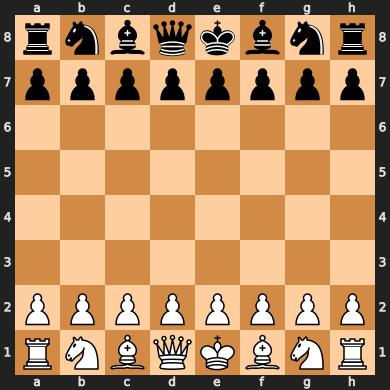

In [15]:
# Test evaluations

# should be about equal
board = chess.Board()
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

('d3d8', [('d3d8', np.float64(27.0), np.float32(0.9073059), np.float32(7.129904)), ('d3c4', np.float64(26.0), np.float32(0.96374017), np.float32(6.6807985)), ('a1b2', np.float64(26.0), np.float32(0.9671008), np.float32(6.6190844)), ('d3g3', np.float64(25.0), np.float32(0.91814756), np.float32(6.424804)), ('a1b1', np.float64(25.0), np.float32(0.96500194), np.float32(6.6575303)), ('d3d5', np.float64(24.0), np.float32(0.92468655), np.float32(6.140549)), ('d3d4', np.float64(21.0), np.float32(0.96042204), np.float32(5.7248683)), ('d3g6', np.float64(20.0), np.float32(0.7700775), np.float32(5.8536806)), ('d3e4', np.float64(20.0), np.float32(0.96083796), np.float32(5.1317463)), ('d3e3', np.float64(20.0), np.float32(0.9157821), np.float32(5.48)), ('d3b3', np.float64(20.0), np.float32(0.92180985), np.float32(5.2013507)), ('a1a2', np.float64(20.0), np.float32(0.9666784), np.float32(5.04108)), ('d3c2', np.float64(18.0), np.float32(0.9698934), np.float32(4.6478386)), ('d3d2', np.float64(17.0), np.f

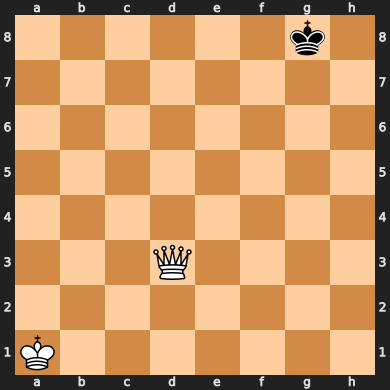

In [16]:
board = chess.Board("6k1/8/8/8/8/3Q4/8/K7 w - - 0 1")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

('g8g7', [('g8g7', np.float64(140.0), np.float32(-0.9428342), np.float32(9.52175)), ('g8f7', np.float64(138.0), np.float32(-0.9314405), np.float32(9.097786)), ('g8f8', np.float64(121.0), np.float32(-0.9457704), np.float32(8.014314)), ('g8h8', np.float64(100.0), np.float32(-0.9116182), np.float32(6.287222))])
initial evaluation:  -0.9671316742897034


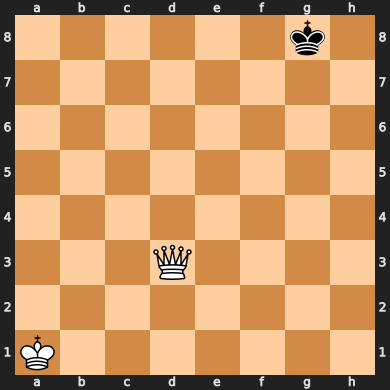

In [17]:
# should be negative (losing)
board = chess.Board("6k1/8/8/8/8/3Q4/8/K7 b - - 0 1")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

('g1f3', [('g1f3', np.float64(42.0), np.float32(0.12203355), np.float32(10.009895)), ('d2d4', np.float64(34.0), np.float32(0.12543103), np.float32(8.151037)), ('c3d5', np.float64(33.0), np.float32(0.26015785), np.float32(7.236685)), ('d1f3', np.float64(28.0), np.float32(0.120895945), np.float32(6.43239)), ('g1e2', np.float64(24.0), np.float32(0.12227288), np.float32(5.8016267)), ('d2d3', np.float64(24.0), np.float32(0.1358423), np.float32(5.7648735)), ('d1e2', np.float64(20.0), np.float32(0.1562494), np.float32(4.783706)), ('h2h3', np.float64(19.0), np.float32(0.17884077), np.float32(4.3493214)), ('g2g3', np.float64(18.0), np.float32(0.07234127), np.float32(4.5175023)), ('h2h4', np.float64(18.0), np.float32(0.1259417), np.float32(3.800901)), ('f2f4', np.float64(18.0), np.float32(0.07832614), np.float32(4.6285787)), ('c3e2', np.float64(17.0), np.float32(0.067514114), np.float32(4.373735)), ('f1b5', np.float64(16.0), np.float32(0.09173573), np.float32(3.7500017)), ('f1c4', np.float64(16.

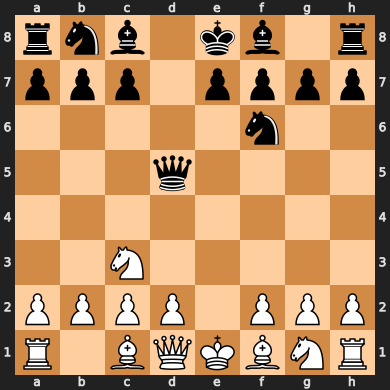

In [18]:
# should be positive (c3d5, somewhat winning)
board = chess.Board("rnb1kb1r/ppp1pppp/5n2/3q4/8/2N5/PPPP1PPP/R1BQKBNR w KQkq - 2 4")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

('d8d4', [('d8d4', np.float64(40.0), np.float32(0.4373509), np.float32(12.229532)), ('b8c6', np.float64(29.0), np.float32(0.034634788), np.float32(10.632145)), ('d8d5', np.float64(23.0), np.float32(-0.086892), np.float32(8.708759)), ('b8d7', np.float64(23.0), np.float32(-0.055274975), np.float32(8.929681)), ('e7e6', np.float64(23.0), np.float32(-0.030356675), np.float32(8.450685)), ('d8d6', np.float64(22.0), np.float32(-0.054095555), np.float32(7.8809767)), ('c8d7', np.float64(22.0), np.float32(-0.053951524), np.float32(8.094659)), ('c7c6', np.float64(22.0), np.float32(-0.034116875), np.float32(7.9496)), ('e7e5', np.float64(22.0), np.float32(0.034647733), np.float32(7.867503)), ('g7g6', np.float64(21.0), np.float32(-0.021798398), np.float32(7.528804)), ('c8f5', np.float64(20.0), np.float32(-0.042748414), np.float32(6.8183546)), ('c8e6', np.float64(19.0), np.float32(0.00048990635), np.float32(7.1219616)), ('d8d7', np.float64(17.0), np.float32(-0.042567097), np.float32(6.1384535)), ('c8g

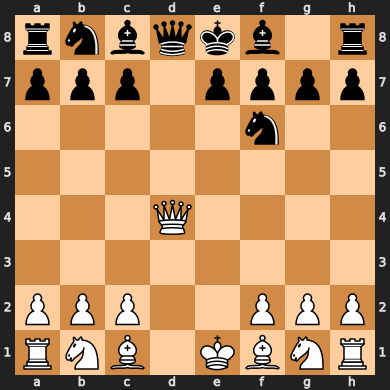

In [19]:
# should be positive (d8d4, somewhat winning)
board = chess.Board("rnbqkb1r/ppp1pppp/5n2/8/3Q4/8/PPP2PPP/RNB1KBNR b KQkq - 2 4")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

('g1f3', [('g1f3', np.float64(47.0), np.float32(-0.16144963), np.float32(9.495741)), ('b1c3', np.float64(36.0), np.float32(-0.21662255), np.float32(7.8648634)), ('b1d2', np.float64(36.0), np.float32(-0.2435967), np.float32(7.3928723)), ('g1e2', np.float64(32.0), np.float32(-0.10411173), np.float32(6.2383876)), ('c2c3', np.float64(28.0), np.float32(-0.16516253), np.float32(5.910591)), ('c1e3', np.float64(24.0), np.float32(-0.12856163), np.float32(5.3682084)), ('f1e2', np.float64(23.0), np.float32(-0.3864438), np.float32(5.5313582)), ('f1d3', np.float64(20.0), np.float32(-0.3876119), np.float32(4.6409063)), ('c1g5', np.float64(20.0), np.float32(-0.4665899), np.float32(4.7902126)), ('f1b5', np.float64(19.0), np.float32(-0.49152413), np.float32(4.6532397)), ('c1d2', np.float64(18.0), np.float32(-0.3840614), np.float32(4.3529444)), ('g1h3', np.float64(17.0), np.float32(-0.5104676), np.float32(4.2215996)), ('b1a3', np.float64(17.0), np.float32(-0.27051464), np.float32(3.7424362)), ('c2c4', n

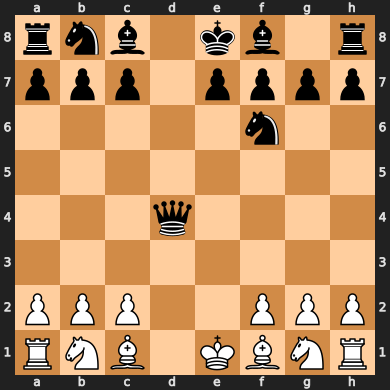

In [20]:
# should be negative (after d8d4, somewhat losing)
board = chess.Board("rnb1kb1r/ppp1pppp/5n2/8/3q4/8/PPP2PPP/RNB1KBNR w KQkq - 0 5")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

('e6e7', [('e6e7', np.float64(116.0), np.float32(0.5885305), np.float32(9.762652)), ('e6f6', np.float64(43.0), np.float32(-0.40637773), np.float32(8.424774)), ('h2g3', np.float64(41.0), np.float32(-0.14911152), np.float32(6.099147)), ('h6f6', np.float64(35.0), np.float32(-0.42852226), np.float32(7.3826733)), ('e6e1', np.float64(27.0), np.float32(-0.2571827), np.float32(4.7762966)), ('e6e3', np.float64(26.0), np.float32(-0.011133052), np.float32(3.5499318)), ('h6g6', np.float64(18.0), np.float32(-0.3510568), np.float32(3.4706678)), ('e6e2', np.float64(18.0), np.float32(-0.31457654), np.float32(3.2237477)), ('h6h7', np.float64(17.0), np.float32(-0.9435773), np.float32(4.480406)), ('h6h3', np.float64(17.0), np.float32(-0.33595783), np.float32(3.1668758)), ('h6g5', np.float64(14.0), np.float32(-0.423417), np.float32(2.0119305)), ('h6h4', np.float64(14.0), np.float32(-0.34546185), np.float32(2.5928214)), ('h2h3', np.float64(14.0), np.float32(-0.5454689), np.float32(2.9238844)), ('h6h5', np.

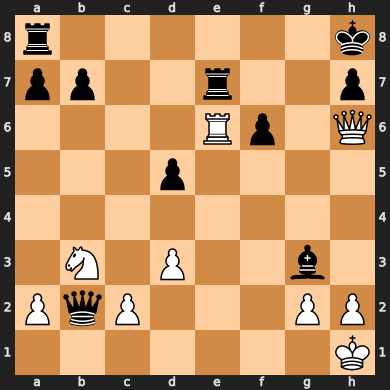

In [21]:
# should be positive (e6e7, somewhat winning)
board = chess.Board("r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2b1/PqP3PP/7K w - - 0 25")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

('d8c8', [('d8c8', np.float64(25.0), np.float32(-0.47961444), np.float32(8.293778)), ('d7e6', np.float64(25.0), np.float32(-0.15424933), np.float32(6.9284816)), ('d7c6', np.float64(24.0), np.float32(-0.61011815), np.float32(8.08938)), ('d7f5', np.float64(24.0), np.float32(-0.5818132), np.float32(7.979486)), ('b7b6', np.float64(23.0), np.float32(-0.74720156), np.float32(8.46299)), ('d7g4', np.float64(22.0), np.float32(-0.5603645), np.float32(7.252145)), ('d7e8', np.float64(18.0), np.float32(-0.32380083), np.float32(5.4659786)), ('g6g5', np.float64(18.0), np.float32(-0.82248074), np.float32(6.8350215)), ('d8e8', np.float64(17.0), np.float32(-0.8463848), np.float32(5.9140034)), ('d7c8', np.float64(17.0), np.float32(-0.75852525), np.float32(6.481085)), ('d6c6', np.float64(17.0), np.float32(-0.56131816), np.float32(4.242343)), ('b8c8', np.float64(16.0), np.float32(-0.83227557), np.float32(5.7676444)), ('d6c7', np.float64(16.0), np.float32(-0.59054875), np.float32(5.478053)), ('h6h5', np.flo

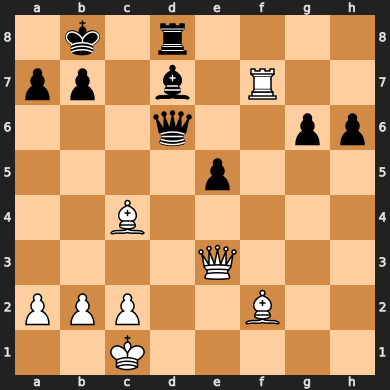

In [22]:
# should be positive (d6d1, mate in 3)
board = chess.Board("1k1r4/pp1b1R2/3q2pp/4p3/2B5/4Q3/PPP2B2/2K5 b - - 0 1")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

('d7g4', [('d7g4', np.float64(45.0), np.float32(-0.81351626), np.float32(10.365902)), ('d7c6', np.float64(37.0), np.float32(-0.9579355), np.float32(8.879022)), ('d7f5', np.float64(32.0), np.float32(-0.95031965), np.float32(7.8964863)), ('d7e6', np.float64(31.0), np.float32(-0.8655978), np.float32(7.328619)), ('d7c8', np.float64(27.0), np.float32(-0.965486), np.float32(6.337137)), ('d7b5', np.float64(26.0), np.float32(-0.9531187), np.float32(6.1493955)), ('b7b6', np.float64(26.0), np.float32(-0.9623015), np.float32(6.5469346)), ('d8c8', np.float64(25.0), np.float32(-0.94662106), np.float32(6.2029524)), ('d7e8', np.float64(25.0), np.float32(-0.94206214), np.float32(6.0438666)), ('g6g5', np.float64(25.0), np.float32(-0.96143067), np.float32(6.0913982)), ('d7h3', np.float64(24.0), np.float32(-0.96426225), np.float32(5.8792915)), ('d7a4', np.float64(22.0), np.float32(-0.9626143), np.float32(5.2957897)), ('d8e8', np.float64(21.0), np.float32(-0.94183993), np.float32(4.862217)), ('h6h5', np.f

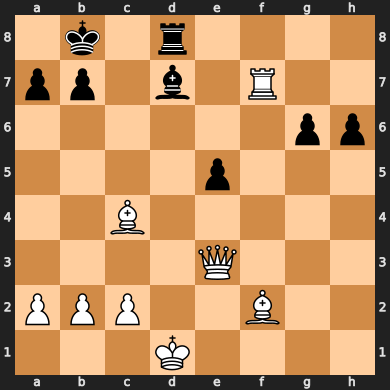

In [23]:
# should be positive (d7g4, mate in 2)
board = chess.Board("1k1r4/pp1b1R2/6pp/4p3/2B5/4Q3/PPP2B2/3K4 b - - 0 2")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

('d1c1', [('d1c1', np.float64(281.0), np.float32(0.65642554), np.float32(9.551445)), ('d1e1', np.float64(218.0), np.float32(0.63394207), np.float32(6.9001074))])
initial evaluation:  0.9162548184394836


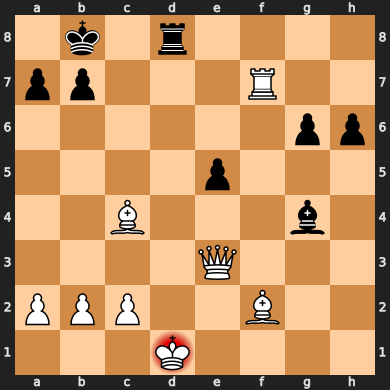

In [24]:
# should be negative (d7g4, mate in 1 coming)
board = chess.Board("1k1r4/pp3R2/6pp/4p3/2B3b1/4Q3/PPP2B2/3K4 w - - 1 3")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

('d8d1', [('d8d1', np.float64(141.0), np.float32(1.0), np.float32(12.972704)), ('b7b6', np.float64(19.0), np.float32(-0.9383526), np.float32(6.052146)), ('d8d3', np.float64(18.0), np.float32(-0.9430944), np.float32(5.556898)), ('g4e6', np.float64(18.0), np.float32(-0.9465992), np.float32(5.5117617)), ('d8d2', np.float64(17.0), np.float32(-0.95809805), np.float32(5.229288)), ('g6g5', np.float64(17.0), np.float32(-0.96164256), np.float32(5.401287)), ('g4f5', np.float64(16.0), np.float32(-0.95841724), np.float32(4.9978275)), ('d8c8', np.float64(15.0), np.float32(-0.96983635), np.float32(5.092163)), ('d8d7', np.float64(15.0), np.float32(-0.9629679), np.float32(4.5438995)), ('d8d4', np.float64(15.0), np.float32(-0.94097954), np.float32(4.788863)), ('g4f3', np.float64(15.0), np.float32(-0.89321434), np.float32(4.863768)), ('g4d1', np.float64(15.0), np.float32(-0.96179533), np.float32(4.670521)), ('d8e8', np.float64(14.0), np.float32(-0.9731555), np.float32(4.3847103)), ('d8d6', np.float64(14

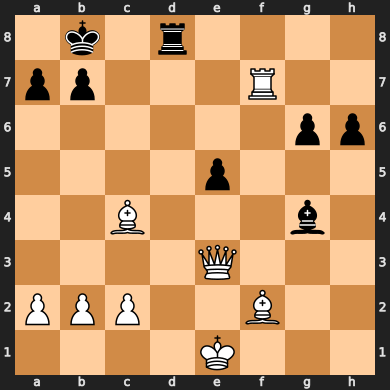

In [25]:
# should be positive (d8d1, mate in 1)
board = chess.Board("1k1r4/pp3R2/6pp/4p3/2B3b1/4Q3/PPP2B2/4K3 b - - 2 3")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board

('f6d5', [('f6d5', np.float64(43.0), np.float32(-0.09745078), np.float32(12.587448)), ('f6g4', np.float64(42.0), np.float32(-0.091828786), np.float32(11.904725)), ('f6e4', np.float64(34.0), np.float32(-0.13077043), np.float32(10.475252)), ('d8c7', np.float64(31.0), np.float32(-0.098671325), np.float32(8.81327)), ('f6g8', np.float64(31.0), np.float32(-0.11525657), np.float32(8.709555)), ('f6h5', np.float64(28.0), np.float32(-0.10007593), np.float32(7.9974966)), ('a7a6', np.float64(26.0), np.float32(-0.03949803), np.float32(7.12715)), ('d7d6', np.float64(24.0), np.float32(-0.07350481), np.float32(6.266839)), ('d7d5', np.float64(23.0), np.float32(-0.08337571), np.float32(6.7301464)), ('d8b6', np.float64(22.0), np.float32(-0.06582041), np.float32(6.1946325)), ('c6e5', np.float64(21.0), np.float32(-0.08014826), np.float32(6.234453)), ('c6b4', np.float64(18.0), np.float32(-0.09566579), np.float32(4.951563)), ('h8g8', np.float64(16.0), np.float32(-0.074816205), np.float32(4.791423)), ('d8a5',

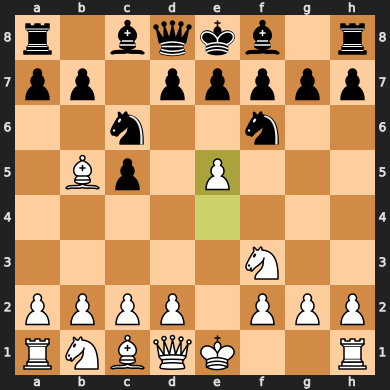

In [26]:
#why does it take on e5??
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board


('e1g1', [('e1g1', np.float64(61.0), np.float32(0.118710645), np.float32(9.781858)), ('b1c3', np.float64(57.0), np.float32(0.100524634), np.float32(8.782784)), ('d2d4', np.float64(44.0), np.float32(0.10663348), np.float32(6.933435)), ('c2c4', np.float64(41.0), np.float32(0.08279296), np.float32(6.7959576)), ('c2c3', np.float64(36.0), np.float32(0.08166467), np.float32(5.557485)), ('b5c4', np.float64(26.0), np.float32(0.073093146), np.float32(4.2333403)), ('d1e2', np.float64(26.0), np.float32(0.08253425), np.float32(4.147439)), ('b1a3', np.float64(25.0), np.float32(0.089042656), np.float32(3.8264318)), ('b5c6', np.float64(24.0), np.float32(0.08353062), np.float32(3.9228392)), ('d2d3', np.float64(22.0), np.float32(0.10560288), np.float32(3.544995)), ('a2a3', np.float64(20.0), np.float32(0.0955433), np.float32(2.8032713)), ('b5a4', np.float64(17.0), np.float32(0.054449797), np.float32(2.51246)), ('f3g5', np.float64(16.0), np.float32(0.0017665323), np.float32(2.672217)), ('h2h3', np.float6

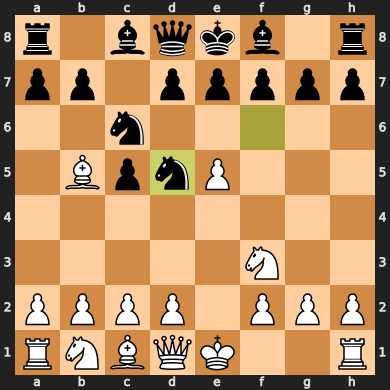

In [27]:
# clearly worse for black?
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
board.push_uci("f6d5")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board


('d5c7', [('d5c7', np.float64(49.0), np.float32(-0.07984496), np.float32(12.317619)), ('d5f4', np.float64(48.0), np.float32(-0.01504389), np.float32(11.034981)), ('d5b6', np.float64(43.0), np.float32(-0.09803007), np.float32(10.526512)), ('d5b4', np.float64(39.0), np.float32(-0.050216574), np.float32(9.574734)), ('e7e6', np.float64(33.0), np.float32(-0.10297246), np.float32(7.5920796)), ('d5f6', np.float64(26.0), np.float32(-0.1376865), np.float32(6.5741854)), ('d5e3', np.float64(24.0), np.float32(-0.08396823), np.float32(5.416757)), ('d5c3', np.float64(24.0), np.float32(-0.14617892), np.float32(5.87128)), ('d8c7', np.float64(23.0), np.float32(-0.12318595), np.float32(5.7172003)), ('g7g6', np.float64(22.0), np.float32(-0.112011686), np.float32(5.3201776)), ('a7a6', np.float64(18.0), np.float32(-0.08987188), np.float32(4.120117)), ('c6b4', np.float64(17.0), np.float32(-0.109566174), np.float32(4.0882196)), ('d8b6', np.float64(15.0), np.float32(-0.112362586), np.float32(3.1671503)), ('h7

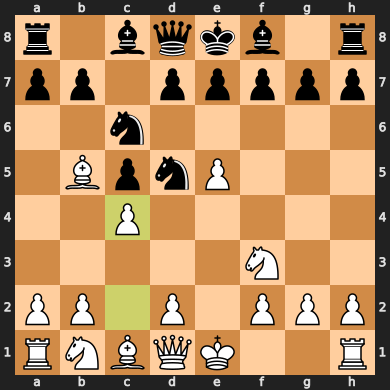

In [28]:
# clearly worse for black?
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
board.push_uci("f6d5")
board.push_uci("c2c4")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board


('e1g1', [('e1g1', np.float64(65.0), np.float32(0.08370216), np.float32(9.216721)), ('b1c3', np.float64(59.0), np.float32(0.08985699), np.float32(8.605267)), ('a2a3', np.float64(55.0), np.float32(0.08100405), np.float32(8.026514)), ('d2d4', np.float64(51.0), np.float32(0.08887564), np.float32(7.072913)), ('b5c6', np.float64(42.0), np.float32(0.04973591), np.float32(6.1199455)), ('d2d3', np.float64(40.0), np.float32(0.06839282), np.float32(5.771614)), ('d1e2', np.float64(29.0), np.float32(-0.052816592), np.float32(4.6630335)), ('b1a3', np.float64(27.0), np.float32(-0.036827754), np.float32(3.8509116)), ('e1e2', np.float64(26.0), np.float32(-0.081801616), np.float32(3.966746)), ('a2a4', np.float64(25.0), np.float32(-0.090032026), np.float32(3.9538484)), ('e1f1', np.float64(15.0), np.float32(-0.03084431), np.float32(2.2337584)), ('b2b3', np.float64(14.0), np.float32(-0.03741465), np.float32(2.0964973)), ('d1c2', np.float64(11.0), np.float32(-0.18770061), np.float32(1.7678306)), ('h2h3', n

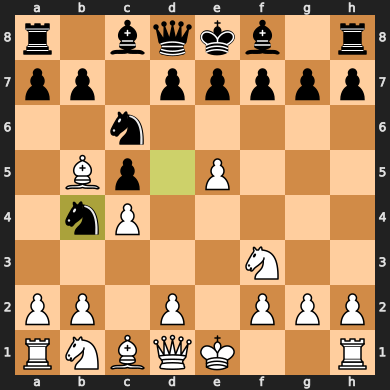

In [29]:
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
board.push_uci("f6d5")
board.push_uci("c2c4")
board.push_uci("d5b4")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board


('e2f3', [('e2f3', np.float64(71.0), np.float32(0.15407902), np.float32(6.744633)), ('d6e7', np.float64(70.0), np.float32(0.18685964), np.float32(6.1092362)), ('g2g3', np.float64(51.0), np.float32(-0.20871438), np.float32(7.082464)), ('b3f3', np.float64(39.0), np.float32(0.18117478), np.float32(3.0481381)), ('e2c4', np.float64(39.0), np.float32(-0.16785315), np.float32(4.8888793)), ('f1d1', np.float64(34.0), np.float32(-0.23858775), np.float32(4.445334)), ('e2d3', np.float64(28.0), np.float32(-0.36899358), np.float32(4.3050103)), ('d6d7', np.float64(26.0), np.float32(-0.34806845), np.float32(3.866014)), ('e2d1', np.float64(25.0), np.float32(-0.21925627), np.float32(3.1324701)), ('f1e1', np.float64(22.0), np.float32(-0.16804622), np.float32(2.3127038)), ('g2g4', np.float64(21.0), np.float32(-0.4966577), np.float32(3.1747122)), ('b3c4', np.float64(19.0), np.float32(-0.31721133), np.float32(2.500091)), ('e2b5', np.float64(9.0), np.float32(-0.37205893), np.float32(1.3519669)), ('b3c3', np.

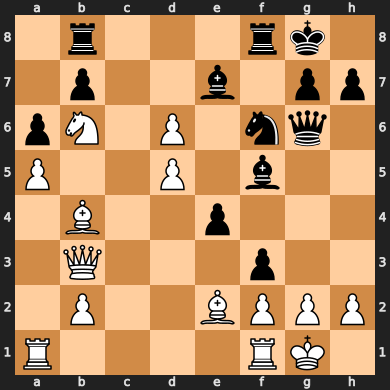

In [30]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board

('f3g3', [('f3g3', np.float64(52.0), np.float32(0.24423367), np.float32(7.6823797)), ('d6e7', np.float64(51.0), np.float32(0.34819955), np.float32(7.1893625)), ('f3h3', np.float64(38.0), np.float32(0.30456638), np.float32(5.729345)), ('f3e2', np.float64(34.0), np.float32(0.05866885), np.float32(6.0398827)), ('f3a3', np.float64(31.0), np.float32(-0.064253226), np.float32(5.5107064)), ('f3e3', np.float64(28.0), np.float32(0.109272785), np.float32(4.58182)), ('f3c3', np.float64(26.0), np.float32(0.06762584), np.float32(4.2328205)), ('f3e4', np.float64(24.0), np.float32(0.46760044), np.float32(2.9570422)), ('f3f4', np.float64(22.0), np.float32(0.09022384), np.float32(3.8257952)), ('f3b3', np.float64(21.0), np.float32(0.03433022), np.float32(3.5772808)), ('a1a3', np.float64(21.0), np.float32(-0.045212984), np.float32(4.188056)), ('f3d1', np.float64(20.0), np.float32(0.041056354), np.float32(3.6576536)), ('f3d3', np.float64(14.0), np.float32(-0.26924342), np.float32(3.1166556)), ('g2g3', np.

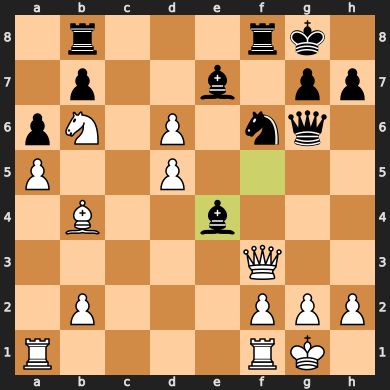

In [31]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board

('e4f3', [('e4f3', np.float64(44.0), np.float32(0.6513921), np.float32(8.885861)), ('e7d6', np.float64(39.0), np.float32(0.6360652), np.float32(7.8670607)), ('e7d8', np.float64(36.0), np.float32(0.5768022), np.float32(7.0269885)), ('f6g4', np.float64(26.0), np.float32(0.2082942), np.float32(5.930815)), ('b8d8', np.float64(24.0), np.float32(0.48444137), np.float32(5.410533)), ('f8d8', np.float64(23.0), np.float32(0.21405825), np.float32(6.049705)), ('g6g5', np.float64(22.0), np.float32(0.1385365), np.float32(5.5996695)), ('f6d5', np.float64(22.0), np.float32(0.25610554), np.float32(5.477641)), ('e4d5', np.float64(20.0), np.float32(0.015408194), np.float32(5.366425)), ('f6h5', np.float64(18.0), np.float32(0.36407623), np.float32(3.9208632)), ('f8f7', np.float64(17.0), np.float32(0.35312268), np.float32(4.1179943)), ('g6f7', np.float64(15.0), np.float32(0.023999121), np.float32(4.384745)), ('g6f5', np.float64(15.0), np.float32(0.056054592), np.float32(3.8036442)), ('e4f5', np.float64(15.0

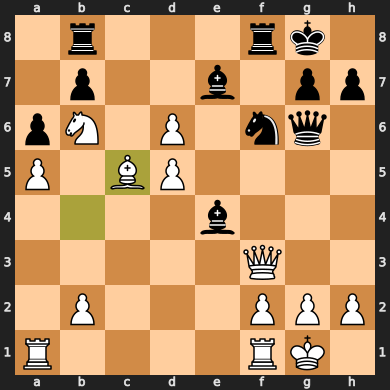

In [32]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
board.push_uci("b4c5")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board

('d6e7', [('d6e7', np.float64(185.0), np.float32(-0.5747545), np.float32(9.112871)), ('d6d7', np.float64(69.0), np.float32(-0.76585627), np.float32(3.8944676)), ('f1e1', np.float64(65.0), np.float32(-0.66698873), np.float32(2.1076772)), ('f1d1', np.float64(53.0), np.float32(-0.7560255), np.float32(2.6626153)), ('g2g3', np.float64(49.0), np.float32(-0.7960027), np.float32(2.6041818)), ('g1h1', np.float64(25.0), np.float32(-0.7026501), np.float32(1.0575057)), ('g2g4', np.float64(20.0), np.float32(-0.8141558), np.float32(1.1555166)), ('f1c1', np.float64(16.0), np.float32(-0.7012179), np.float32(0.5595684)), ('h2h3', np.float64(7.0), np.float32(-0.87624633), np.float32(0.32609236)), ('b6c8', np.float64(1.0), np.float32(-0.93526256), np.float32(-1.3005881)), ('c5d4', np.float64(1.0), np.float32(-0.94469136), np.float32(-0.25497627)), ('c5a3', np.float64(1.0), np.float32(-0.94094336), np.float32(-1.1504915)), ('f1b1', np.float64(1.0), np.float32(-0.9540946), np.float32(-0.82203984)), ('a1a3'

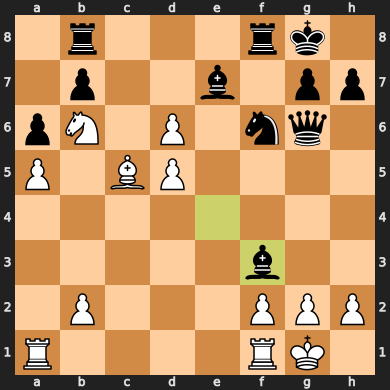

In [33]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
board.push_uci("b4c5")
board.push_uci("e4f3")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board

('e7d6', [('e7d6', np.float64(30.0), np.float32(0.91699064), np.float32(7.2714353)), ('g6g2', np.float64(29.0), np.float32(1.0), np.float32(6.592803)), ('e7d8', np.float64(26.0), np.float32(0.9572569), np.float32(5.885623)), ('f3g2', np.float64(26.0), np.float32(0.9079566), np.float32(6.0998745)), ('f6d5', np.float64(23.0), np.float32(0.85018605), np.float32(5.7000923)), ('f6g4', np.float64(21.0), np.float32(0.8037264), np.float32(5.3968315)), ('g6g5', np.float64(20.0), np.float32(0.8399935), np.float32(4.9252987)), ('f6e4', np.float64(20.0), np.float32(0.9390108), np.float32(4.720062)), ('g6h6', np.float64(18.0), np.float32(0.797025), np.float32(4.068663)), ('f8d8', np.float64(17.0), np.float32(0.7695542), np.float32(4.1892924)), ('g6f7', np.float64(15.0), np.float32(0.6192105), np.float32(3.931012)), ('g6e4', np.float64(14.0), np.float32(0.5097308), np.float32(3.8618212)), ('f3d5', np.float64(14.0), np.float32(0.70705557), np.float32(3.6873055)), ('f3g4', np.float64(14.0), np.float32

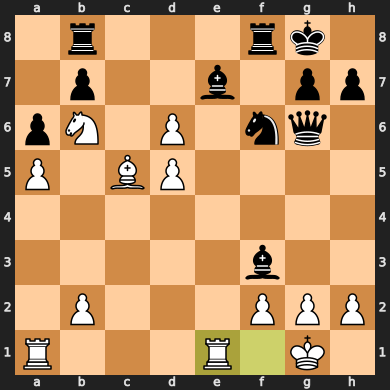

In [34]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
board.push_uci("b4c5")
board.push_uci("e4f3")
board.push_uci("f1e1")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_policy_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board